# Particle Swarm Optimization (PSO) for Algorithmic Trading Strategy Optimization

Particle Swarm Optimization (PSO) is a population-based heuristic optimization technique inspired by the social behavior of bird flocking or fish schooling.

In this notebook, we will:
1. Implement a generic, robust PSO algorithm.
2. Define a Dual Moving Average Crossover trading strategy.
3. Formulate the fitness function based on the historical trading performance (cumulative return).
4. Run PSO to optimize the short-term and long-term moving average window parameters.
5. Visualize the optimization process and the resulting trading performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Set random seed for reproducibility
np.random.seed(42)

## Step 1: Fetch Historical Market Data
We will download historical price data for a stock (e.g., Apple - AAPL) using `yfinance` to serve as our trading dataset.

In [2]:
# Fetch historical daily data for Apple
data = yf.download('AAPL', start='2022-01-01', end='2023-12-31')
data = data[['Close']].copy()
# Flatten columns in case of MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

display(data.head())

/tmp/ipykernel_4782/1859260142.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2022-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


Price,Close
Date,
2022-01-03,177.786377
2022-01-04,175.529968
2022-01-05,170.860916
2022-01-06,168.008682
2022-01-07,168.174728


## Step 2: Define the Trading Strategy and Fitness Function
Our trading strategy is a Simple Moving Average (SMA) crossover.
- Buy (Go Long) when the Short SMA crosses above the Long SMA.
- Sell (Go Short/Flat) when the Short SMA crosses below the Long SMA.

Our objective (fitness) is to **maximize the cumulative return** of this strategy over the historical period. We optimize two parameters:
- $x_0$: Short-term SMA window (range [5, 50])
- $x_1$: Long-term SMA window (range [50, 200])

In [3]:
def evaluate_strategy(short_window, long_window, df):
    """
    Evaluates the cumulative return of an SMA crossover strategy.
    """
    # Ensure window sizes are positive integers and short < long
    short_window = int(round(short_window))
    long_window = int(round(long_window))

    if short_window >= long_window or short_window < 2 or long_window < 10:
        return -1.0  # Return low fitness for invalid parameters

    temp_df = df.copy()
    temp_df['Short_SMA'] = temp_df['Close'].rolling(window=short_window).mean()
    temp_df['Long_SMA'] = temp_df['Close'].rolling(window=long_window).mean()

    # Drop rows with NaN values resulting from rolling windows
    temp_df.dropna(inplace=True)
    if len(temp_df) == 0:
        return -1.0

    # Generate signals
    temp_df['Signal'] = 0.0
    temp_df.loc[temp_df['Short_SMA'] > temp_df['Long_SMA'], 'Signal'] = 1.0

    # Calculate daily returns
    temp_df['Market_Return'] = temp_df['Close'].pct_change()
    # Shift signal to prevent look-ahead bias (we trade on the next day's open/close based on today's signal)
    temp_df['Strategy_Return'] = temp_df['Signal'].shift(1) * temp_df['Market_Return']

    # Calculate cumulative return
    cumulative_return = (1 + temp_df['Strategy_Return'].fillna(0)).prod() - 1
    return cumulative_return

## Step 3: Implement Particle Swarm Optimization (PSO)
We will define the `Particle` class and the main `PSO` execution function.

In [4]:
class Particle:
    def __init__(self, bounds):
        self.bounds = bounds  # List of tuples [(min, max), ...]
        self.position = np.array([np.random.uniform(b[0], b[1]) for b in bounds])
        self.velocity = np.array([np.random.uniform(-abs(b[1]-b[0])/10, abs(b[1]-b[0])/10) for b in bounds])
        self.best_position = np.copy(self.position)
        self.best_fitness = -np.inf  # We are maximizing return
        self.fitness = -np.inf

    def update_position(self):
        self.position += self.velocity
        # Clip position to boundaries
        for i in range(len(self.bounds)):
            self.position[i] = np.clip(self.position[i], self.bounds[i][0], self.bounds[i][1])

def run_pso(df, num_particles=15, max_iter=30, w=0.5, c1=1.5, c2=1.5):
    # Parameters bounds: short_window in [5, 50], long_window in [50, 200]
    bounds = [(5, 50), (50, 200)]

    # Initialize swarm
    swarm = [Particle(bounds) for _ in range(num_particles)]

    global_best_position = None
    global_best_fitness = -np.inf

    history = []

    for it in range(max_iter):
        for particle in swarm:
            # Evaluate fitness
            particle.fitness = evaluate_strategy(particle.position[0], particle.position[1], df)

            # Update individual best
            if particle.fitness > particle.best_fitness:
                particle.best_fitness = particle.fitness
                particle.best_position = np.copy(particle.position)

            # Update global best
            if particle.fitness > global_best_fitness:
                global_best_fitness = particle.fitness
                global_best_position = np.copy(particle.position)

        # Update velocities and positions
        for particle in swarm:
            r1, r2 = np.random.rand(), np.random.rand()
            cognitive_velocity = c1 * r1 * (particle.best_position - particle.position)
            social_velocity = c2 * r2 * (global_best_position - particle.position)
            particle.velocity = w * particle.velocity + cognitive_velocity + social_velocity
            particle.update_position()

        history.append(global_best_fitness)
        print(f"Iteration {it+1:02d}/{max_iter} - Global Best Return: {global_best_fitness:.2%}")

    return global_best_position, global_best_fitness, history

## Step 4: Run Optimization and Visualize Results

In [5]:
# Execute the PSO optimization
best_params, best_fitness, fit_history = run_pso(data, num_particles=20, max_iter=25)

short_opt, long_opt = int(round(best_params[0])), int(round(best_params[1]))
print(f"\nOptimization Finished!")
print(f"Optimal Short Window SMA: {short_opt}")
print(f"Optimal Long Window SMA: {long_opt}")
print(f"Maximized Cumulative Return: {best_fitness:.2%}")

Iteration 01/25 - Global Best Return: 25.76%
Iteration 02/25 - Global Best Return: 31.76%
Iteration 03/25 - Global Best Return: 31.76%
Iteration 04/25 - Global Best Return: 31.76%
Iteration 05/25 - Global Best Return: 33.03%
Iteration 06/25 - Global Best Return: 33.03%
Iteration 07/25 - Global Best Return: 33.03%
Iteration 08/25 - Global Best Return: 33.03%
Iteration 09/25 - Global Best Return: 33.03%
Iteration 10/25 - Global Best Return: 33.03%
Iteration 11/25 - Global Best Return: 33.03%
Iteration 12/25 - Global Best Return: 33.03%
Iteration 13/25 - Global Best Return: 33.03%
Iteration 14/25 - Global Best Return: 33.03%
Iteration 15/25 - Global Best Return: 33.03%
Iteration 16/25 - Global Best Return: 33.03%
Iteration 17/25 - Global Best Return: 33.03%
Iteration 18/25 - Global Best Return: 33.03%
Iteration 19/25 - Global Best Return: 33.03%
Iteration 20/25 - Global Best Return: 33.03%
Iteration 21/25 - Global Best Return: 33.03%
Iteration 22/25 - Global Best Return: 33.03%
Iteration 

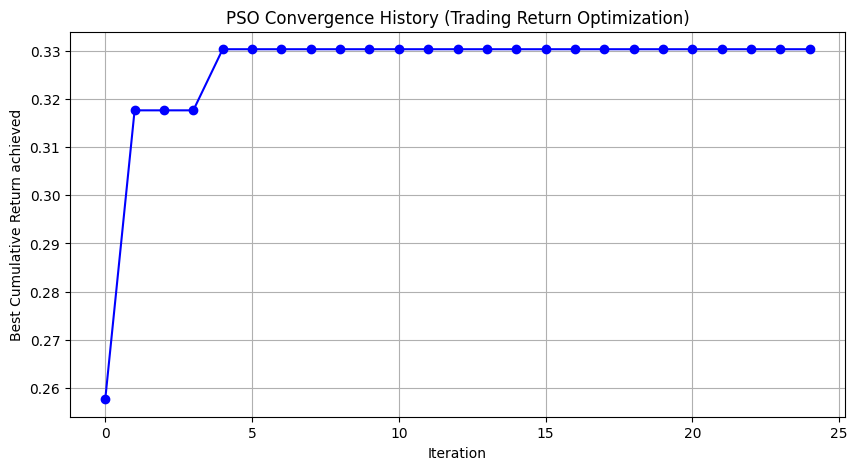

In [6]:
# Plot PSO Convergence Profile
plt.figure(figsize=(10, 5))
plt.plot(fit_history, marker='o', color='b')
plt.title('PSO Convergence History (Trading Return Optimization)')
plt.xlabel('Iteration')
plt.ylabel('Best Cumulative Return achieved')
plt.grid(True)
plt.show()